In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)
sns.set(style="whitegrid")

In [25]:
events_obs_df = pd.read_csv(
    "../data/processed/ethiopia_new.csv",
    parse_dates=["observation_date", "period_start", "period_end", "collection_date"]
)

impact_links_df = pd.read_csv(
    "../data/processed/impact_new.csv",
    parse_dates=["observation_date", "collection_date"]
)


C:\Users\ruthg\AppData\Local\Temp\ipykernel_28884\1202287608.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  events_obs_df = pd.read_csv(


In [ ]:
events_obs_df["record_type"] = (
    events_obs_df["record_type"].astype(str).str.strip().str.lower()
)
impact_links_df["record_type"] = (
    impact_links_df["record_type"].astype(str).str.strip().str.lower()
)

In [ ]:
events_df = events_obs_df[events_obs_df["record_type"] == "event"].copy()
observations_df = events_obs_df[events_obs_df["record_type"] == "observation"].copy()

len(events_df), len(observations_df), len(impact_links_df)

(12, 36, 18)

In [ ]:
event_impact_df = impact_links_df.merge(
    events_df[[
        "record_id",
        "indicator",          
        "category",
        "observation_date"
    ]],
    left_on="parent_id",
    right_on="record_id",
    how="left",
    suffixes=("", "_event")
)

event_impact_df.rename(columns={
    "indicator": "event_name",
    "observation_date": "event_date"
}, inplace=True)

event_impact_df[["parent_id", "event_name", "event_date"]].head()


,parent_id,event_name,event_date
0,EVT_0001,Telebirr effect on Account Ownership,2021-05-17
1,EVT_0001,Telebirr effect on Telebirr Users,2021-05-17
2,EVT_0001,Telebirr effect on P2P Transactions,2021-05-17
3,EVT_0002,Safaricom effect on 4G Coverage,2022-08-01
4,EVT_0002,Safaricom effect on Data Affordability,2022-08-01


In [ ]:
event_impact_df["event_name"] = event_impact_df["event_name"].fillna("Unknown Event")
event_impact_df["related_indicator"] = event_impact_df["related_indicator"].fillna("Unknown Indicator")


event_impact_df["impact_value"] = (
    event_impact_df["impact_estimate"]
    .fillna(event_impact_df["impact_magnitude"])
    .fillna(0)
)

event_impact_df["direction"] = event_impact_df["impact_direction"].map({
    "increase": 1,
    "decrease": -1
}).fillna(0)

event_impact_df["signed_impact"] = (
    event_impact_df["direction"] * event_impact_df["impact_value"]
)


In [ ]:
event_impact_df["impact_value"] = pd.to_numeric(
    event_impact_df["impact_value"],
    errors="coerce"
)

event_impact_df["signed_impact"] = pd.to_numeric(
    event_impact_df["signed_impact"],
    errors="coerce"
).fillna(0)
event_impact_df["signed_impact"].dtype

dtype('float64')

In [32]:
association_matrix = event_impact_df.pivot_table(
    index="event_name",
    columns="related_indicator",
    values="signed_impact",
    aggfunc="mean",
    fill_value=0
)


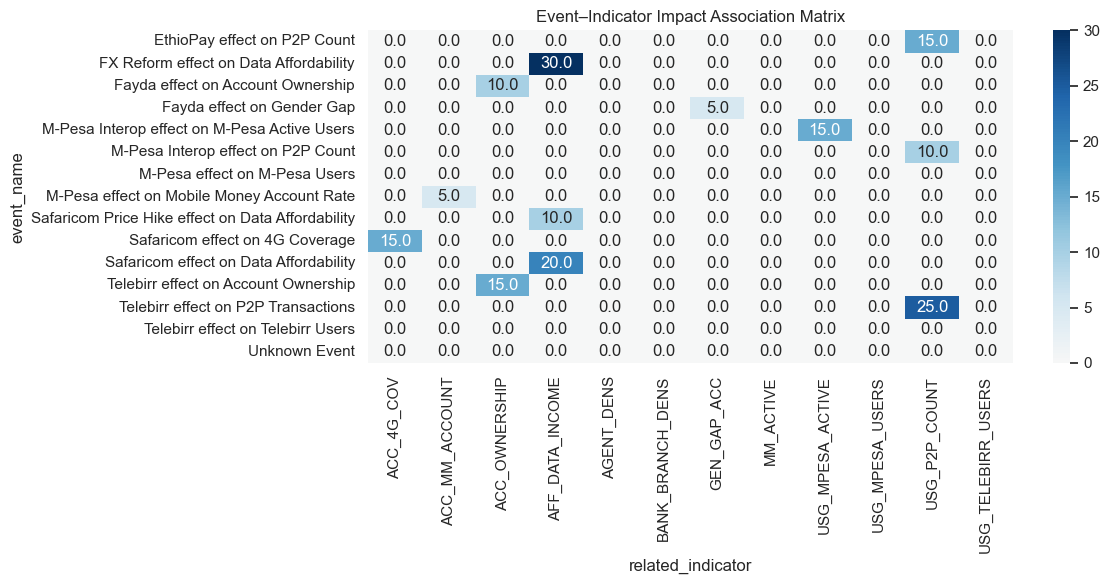

In [33]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    association_matrix,
    cmap="RdBu",
    center=0,
    annot=True,
    fmt=".1f"
)
plt.title("Event–Indicator Impact Association Matrix")
plt.tight_layout()
plt.show()


In [ ]:
impact_rows = []
timeline = pd.date_range(start="2014-01-01", end="2026-12-01", freq="MS")

for _, row in event_impact_df.iterrows():
    for t in timeline:
        months_since = (
            (t.year - row["event_date"].year) * 12 +
            (t.month - row["event_date"].month) -
            row["lag_months"]
        )

        shape = "ramp" if row["evidence_basis"] in ["literature","comparable"] else "step"

        if months_since < 0:
            impact = 0
        else:
            if shape == "step":
                impact = row["signed_impact"]
                impact = row["signed_impact"] * min(months_since/24, 1)

        impact_rows.append({
            "date": t,
            "indicator": row["related_indicator"] if pd.notna(row["related_indicator"]) else "Unknown Indicator",
            "impact": impact
        })

indicator_impact_ts = pd.DataFrame(impact_rows)

In [36]:
indicator_impact_ts = (
    indicator_impact_ts
    .groupby(["date", "indicator"])["impact"]
    .sum()
    .reset_index()
)

indicator_impact_ts.head()

,date,indicator,impact
0,2014-01-01,ACC_4G_COV,0.0
1,2014-01-01,ACC_MM_ACCOUNT,0.0
2,2014-01-01,ACC_OWNERSHIP,0.0
3,2014-01-01,AFF_DATA_INCOME,0.0
4,2014-01-01,AGENT_DENS,0.0


In [34]:
confidence_map = {
    "high": "High",
    "medium": "Medium",
    "low": "Low"
}

event_impact_df["confidence_label"] = (
    event_impact_df["confidence"]
    .astype(str)
    .str.lower()
    .map(confidence_map)
    .fillna("Low")
)


In [ ]:
association_matrix.to_csv("../data/processed/event_indicator_matrix.csv")

indicator_impact_ts.to_csv("../data/processed/indicator_impact_timeseries.csv", index=False)

event_impact_df[[
    "event_name",
    "related_indicator",
    "signed_impact",
    "lag_months",
    "evidence_basis",
    "comparable_country",
    "confidence_label"
]].to_csv("../data/processed/impact_documentation.csv", index=False)

All Task 3 deliverables saved to ../outputs/


In [38]:
yearly_impact = indicator_impact_ts.groupby([indicator_impact_ts.date.dt.year, "indicator"])["impact"].sum().reset_index()